In [1]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import Tratar_dados.converter_txt_Lista as cl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
arquivo_Gemini_Respostas = r"/workspaces/Sites_Design_Manipulativos/Data/Resultados_Completos/Gemini_respostas_texto.txt"
arquivo_Openai_Respostas = r"/workspaces/Sites_Design_Manipulativos/Data/Resultados_Completos/Openai_respostas_texto.txt"

In [10]:
df_Gemini = cl.converter_Txt(arquivo_Gemini_Respostas).assign(Fonte = 'Gemini')
df_Openai = cl.converter_Txt(arquivo_Openai_Respostas).assign(Fonte = 'Openai')

In [11]:
print(f"Gemini: \n{df_Gemini['manipulative_design'].value_counts()} \n")
print(f"Openai: \n{df_Openai['manipulative_design'].value_counts()}")

Gemini: 
manipulative_design
True     24
False    21
Name: count, dtype: int64 

Openai: 
manipulative_design
True     27
False    18
Name: count, dtype: int64


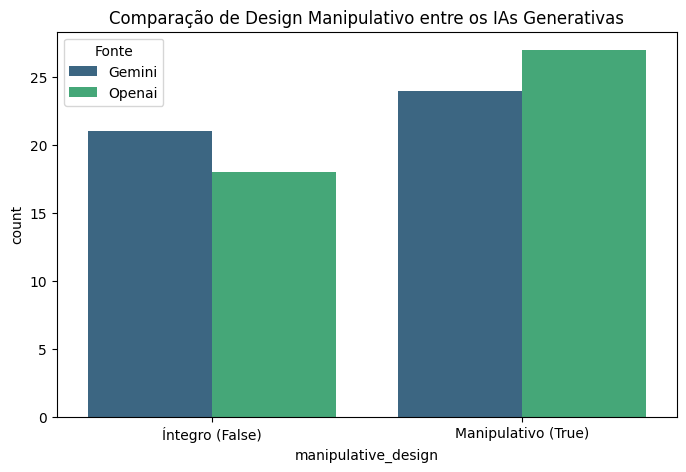

In [12]:
df_final = pd.concat([df_Gemini, df_Openai])

plt.figure(figsize=(8, 5))
sns.countplot(data = df_final, x = 'manipulative_design', hue = 'Fonte', palette = 'viridis')

plt.title("Comparação de Design Manipulativo entre os IAs Generativas")
plt.xticks([0, 1], ['Íntegro (False)', 'Manipulativo (True)'])
plt.show()

In [13]:
df_Gabarito = pd.read_excel(r"/workspaces/Sites_Design_Manipulativos/Data/Gabarito_Resultados.xlsx")
df_Gabarito.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   url                           29 non-null     str  
 1   manipulative_design_Gabarito  29 non-null     bool 
dtypes: bool(1), str(1)
memory usage: 393.0 bytes


In [14]:
df_Gabarito

,url,manipulative_design_Gabarito
0,www.ludoeducativo.com.br/pt/,False
1,www.fafaconta.com.br,False
2,www.palavracantada.com.br,False
3,https://www.khanacademy.org/kids,False
4,https://futura.frm.org.br/,False
5,https://www.smartick.com/,False
6,https://plenarinho.leg.br/,False
7,https://pbskids.org/,False
8,https://www.nasa.gov/learning-resources/nasa-k...,False
9,https://turminha.mpf.mp.br/,False
